# Credit Card Fraud Detection
 **Machine Learning aplicado à detecção de fraudes em cartões de crédito**

## Resumo Executivo

### Problema de negócio
Detectar transações fraudulentas em cartões de crédito em tempo real, minimizando
tanto o bloqueio indevido de clientes legítimos (falso positivo) quanto fraudes não
detectadas (falso negativo).

### Abordagem
Testamos 3 famílias de modelos (Regressão Logística, Random Forest, XGBoost) e
3 estratégias de balanceamento de classes, avaliados com métricas apropriadas para
o extremo desbalanceamento da base (0,17% de fraude).



In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e divisão dos dados
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Modelos de Machine Learning
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_val_score

# Avaliação de modelos
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('CREDIT_CARD_FRAUD.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# Visão Geral do Dataset
print(f"Shape: {df.shape}")
print(f"\nTipos de dados:\n{df.dtypes.value_counts()}")
print(f"\nValores faltantes: {df.isna().sum().sum()}")
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")

Shape: (284807, 31)

Tipos de dados:
float64    30
int64       1
Name: count, dtype: int64

Valores faltantes: 0

Linhas duplicadas: 1081


Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


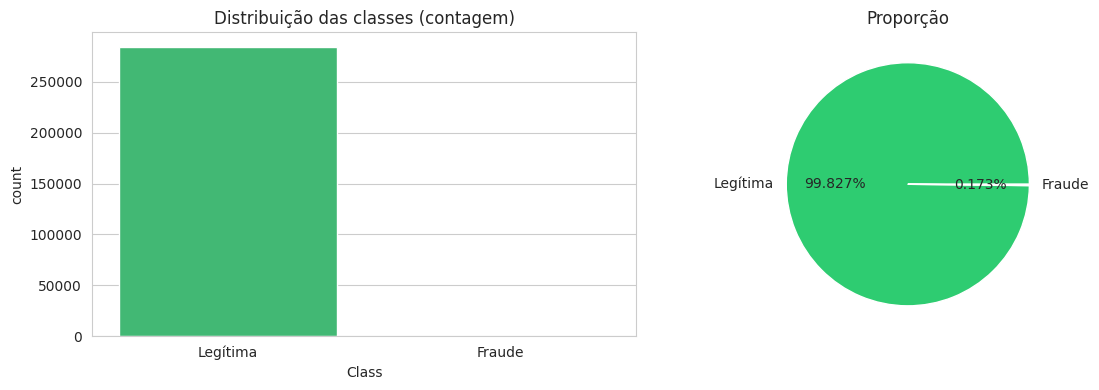

In [3]:
# Visualizando e analisando o desbalanceamento da variável Class
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print(class_counts)
print(f"\n{class_pct}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Class', data=df, ax=axes[0], hue='Class', legend=False, palette=['#2ecc71','#e74c3c'])
axes[0].set_title('Distribuição das classes (contagem)')
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['Legítima','Fraude'])

class_counts.plot.pie(autopct='%1.3f%%', labels=['Legítima','Fraude'],
                       colors=['#2ecc71','#e74c3c'], ax=axes[1])
axes[1].set_ylabel('')
axes[1].set_title('Proporção')
plt.savefig('class_distribution.png')
plt.tight_layout()
plt.show()

Observando essa análise, apenas 492 de 284.807 transações (0,173%) são fraude. É um desbalanceamento de aproximadamente 1:578.

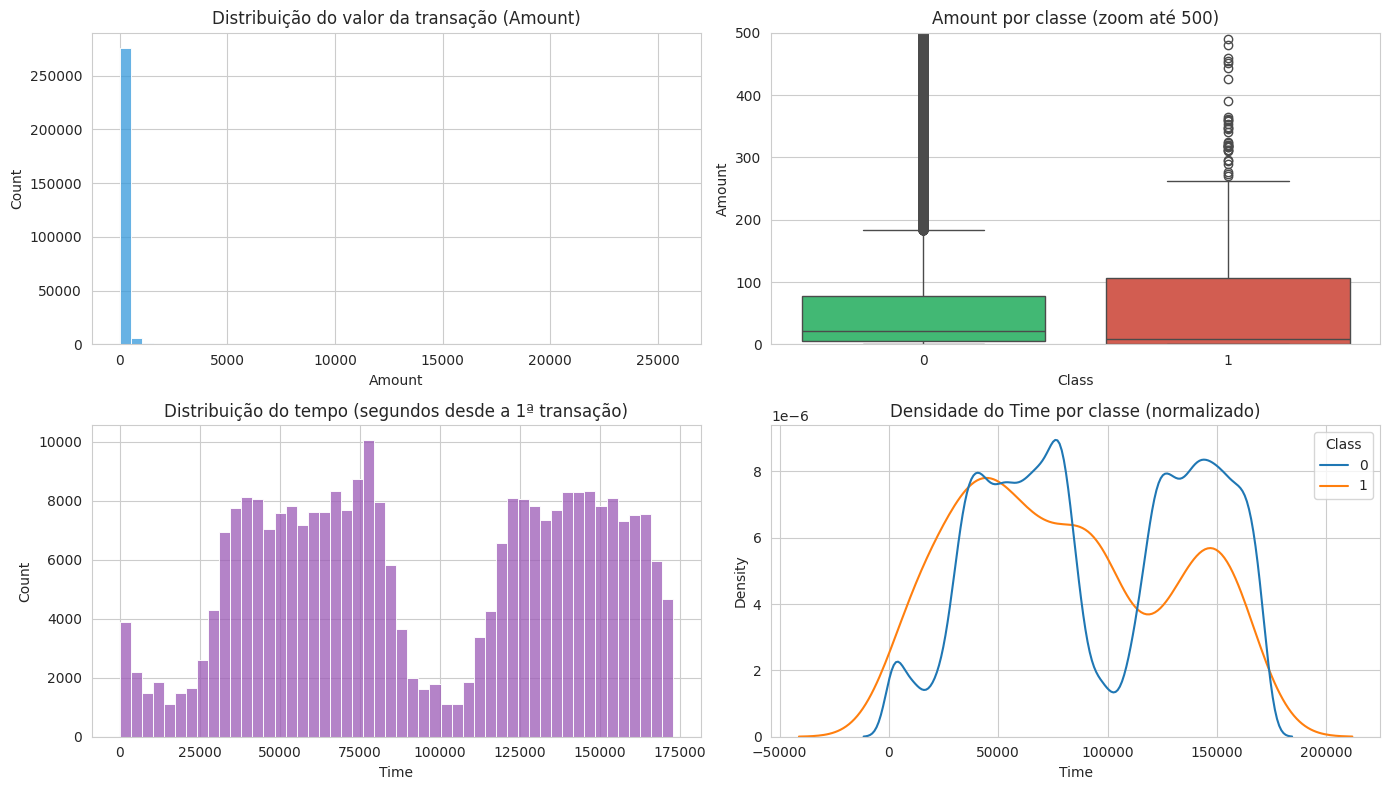

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [4]:
# Distribuição das variáveis Time e Amount
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df['Amount'], bins=50, ax=axes[0,0], color='#3498db')
axes[0,0].set_title('Distribuição do valor da transação (Amount)')

sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0,1], hue='Class', legend=False, palette=['#2ecc71','#e74c3c'])
axes[0,1].set_ylim(0, 500)  # cortando outliers extremos pra visualizar melhor
axes[0,1].set_title('Amount por classe (zoom até 500)')

sns.histplot(df['Time'], bins=50, ax=axes[1,0], color='#9b59b6')
axes[1,0].set_title('Distribuição do tempo (segundos desde a 1ª transação)')

sns.kdeplot(data=df, x='Time', hue='Class', ax=axes[1,1], common_norm=False)
axes[1,1].set_title('Densidade do Time por classe (normalizado)')

plt.savefig('time_amount_distribution.png')
plt.tight_layout()
plt.show()

print(df.groupby('Class')['Amount'].describe())

 Percebe-se que transações fraudulentas têm Amount médio de 122,21 contra 88,29 das legítimas, mas a mediana da fraude (9,25) é menor que a das legítimas (22,00). Ou seja, fraude não é "valor alto" de forma simples — tem muita fraude de valor baixo e algumas de valor bem alto puxando a média. Amount sozinho não é um bom discriminador linear, presumo que precisarei de modelos não lineares com Random Forest/XGBoost.

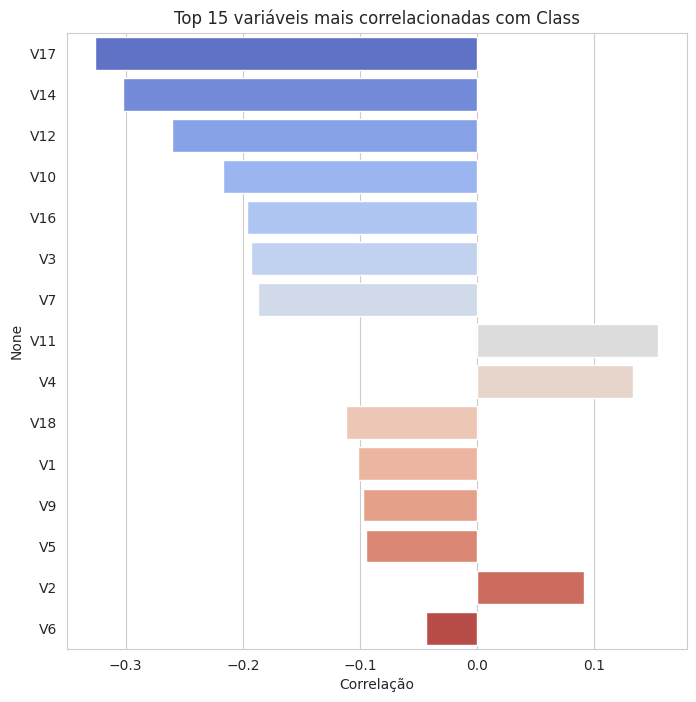

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64


In [5]:
# Correlação com a variável target
corr_target = df.corr(numeric_only=True)['Class'].drop('Class').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8,8))
top_corr = corr_target.head(15)
sns.barplot(x=top_corr.values, y=top_corr.index, hue=top_corr.index, legend=False, palette='coolwarm')
plt.title('Top 15 variáveis mais correlacionadas com Class')
plt.xlabel('Correlação')
plt.savefig('correlation_class.png')
plt.show()

print(corr_target.head(10))



V17, V14, V12 e V10 são as variáveis (já anonimizadas pelo PCA) com maior correlação (negativa) com fraude. Isso é útil pra depois, quando for olhar feature importance do XGBoost/Random Forest — se essas mesmas variáveis aparecerem no topo, dá mais confiança de que o modelo está capturando sinal real, não ruído.

In [6]:
# Limpeza: removendo duplicatas
print(f"Antes: {df.shape[0]} linhas")
df = df.drop_duplicates()
print(f"Depois: {df.shape[0]} linhas ({df.duplicated().sum()} duplicatas restantes)")

# conferindo se o desbalanceamento mudou muito
print(df['Class'].value_counts(normalize=True) * 100)

Antes: 284807 linhas
Depois: 283726 linhas (0 duplicatas restantes)
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [7]:
# Normalização de Amount e Time
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

df = df.drop(columns=['Amount', 'Time'])
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244200,-1.996823
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342584,-1.996823
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.158900,-1.996802
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.139886,-1.996802
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073813,-1.996781


Por que StandardScaler e não MinMax? Porque V1-V28 já saíram do PCA com média ~0 e variância unitária (padrão do sklearn PCA). Pra manter todas as features na mesma escala, Amount e Time precisam seguir o mesmo tratamento (padronização z-score), não normalização 0-1.

In [8]:
# Separando as variáveis preditoras (X) da variável alvo (y)
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Treino: {X_train.shape[0]} linhas | Fraudes: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Teste:  {X_test.shape[0]} linhas | Fraudes: {y_test.sum()} ({y_test.mean()*100:.3f}%)")


Treino: 226980 linhas | Fraudes: 378 (0.167%)
Teste:  56746 linhas | Fraudes: 95 (0.167%)


In [9]:
!pip install -q imbalanced-learn

In [10]:
# Construindo os modelos - Baseline sem balanceamento (Regressão Logística)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, roc_auc_score

clf_base = LogisticRegression(max_iter=1000, random_state=42)
clf_base.fit(X_train, y_train)

y_pred_base = clf_base.predict(X_test)
y_proba_base = clf_base.predict_proba(X_test)[:, 1]

print("=== Baseline (sem balanceamento) ===")
print(classification_report(y_test, y_pred_base, digits=3))
print(f"AUC-PR: {average_precision_score(y_test, y_proba_base):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_base):.4f}")
print(confusion_matrix(y_test, y_pred_base))

=== Baseline (sem balanceamento) ===
              precision    recall  f1-score   support

           0      0.999     1.000     1.000     56651
           1      0.848     0.589     0.696        95

    accuracy                          0.999     56746
   macro avg      0.924     0.795     0.848     56746
weighted avg      0.999     0.999     0.999     56746

AUC-PR: 0.6935
ROC-AUC: 0.9584
[[56641    10]
 [   39    56]]


Temos o precision de 84,8% e recall de 58,9% para a classe fraude. Em números absolutos: de 95 fraudes no teste, o modelo detecta 56 e erra 39 (falsos negativos) — mas quando ele diz "é fraude", acerta 85% das vezes (poucos falsos positivos: só 10).

In [11]:
# Estratégia 1:class_weight='balanced'
clf_weighted = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf_weighted.fit(X_train, y_train)

y_pred_w = clf_weighted.predict(X_test)
y_proba_w = clf_weighted.predict_proba(X_test)[:, 1]

print("=== class_weight='balanced' ===")
print(classification_report(y_test, y_pred_w, digits=3))
print(f"AUC-PR: {average_precision_score(y_test, y_proba_w):.4f}")
print(confusion_matrix(y_test, y_pred_w))

=== class_weight='balanced' ===
              precision    recall  f1-score   support

           0      1.000     0.975     0.987     56651
           1      0.056     0.874     0.105        95

    accuracy                          0.975     56746
   macro avg      0.528     0.925     0.546     56746
weighted avg      0.998     0.975     0.986     56746

AUC-PR: 0.6720
[[55255  1396]
 [   12    83]]


 O recall sobe pra 87,4% (ótimo, pega quase todas as fraudes!) mas a precision despenca pra 5,6% — de 1.479 transações marcadas como fraude, só 83 são fraude de verdade. Isso significa 1.396 clientes legítimos barrados ou incomodados por falso positivo.

In [12]:
# Estratégia 2:SMOTE(oversampling sintético)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Antes do SMOTE: {y_train.value_counts().to_dict()}")
print(f"Depois do SMOTE: {y_train_smote.value_counts().to_dict()}")

clf_smote = LogisticRegression(max_iter=1000, random_state=42)
clf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = clf_smote.predict(X_test)
y_proba_smote = clf_smote.predict_proba(X_test)[:, 1]

print("\n=== SMOTE ===")
print(classification_report(y_test, y_pred_smote, digits=3))
print(f"AUC-PR: {average_precision_score(y_test, y_proba_smote):.4f}")
print(confusion_matrix(y_test, y_pred_smote))


Antes do SMOTE: {0: 226602, 1: 378}
Depois do SMOTE: {0: 226602, 1: 226602}

=== SMOTE ===
              precision    recall  f1-score   support

           0      1.000     0.974     0.987     56651
           1      0.053     0.874     0.100        95

    accuracy                          0.974     56746
   macro avg      0.526     0.924     0.543     56746
weighted avg      0.998     0.974     0.985     56746

AUC-PR: 0.6768
[[55172  1479]
 [   12    83]]


In [13]:
# Estratégia 3:Random Undersampling
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f"Depois do undersampling: {y_train_rus.value_counts().to_dict()}")

clf_rus = LogisticRegression(max_iter=1000, random_state=42)
clf_rus.fit(X_train_rus, y_train_rus)

y_pred_rus = clf_rus.predict(X_test)
y_proba_rus = clf_rus.predict_proba(X_test)[:, 1]

print("\n=== Random UnderSampling ===")
print(classification_report(y_test, y_pred_rus, digits=3))
print(f"AUC-PR: {average_precision_score(y_test, y_proba_rus):.4f}")
print(confusion_matrix(y_test, y_pred_rus))

Depois do undersampling: {0: 378, 1: 378}

=== Random UnderSampling ===
              precision    recall  f1-score   support

           0      1.000     0.973     0.986     56651
           1      0.052     0.874     0.098        95

    accuracy                          0.973     56746
   macro avg      0.526     0.923     0.542     56746
weighted avg      0.998     0.973     0.985     56746

AUC-PR: 0.6182
[[55137  1514]
 [   12    83]]


Undersampling descarta a maior parte dos dados legítimos (de ~227 mil pra ~380 registros de treino), então é rápido, mas joga fora muita informação. Costuma performar pior que SMOTE em datasets grandes como esse — mas vale comparar com números reais, não achismo.

                       Precision  Recall  F1-Score  AUC-PR
Estratégia                                                
Sem balanceamento         0.8485  0.5895    0.6957  0.6935
class_weight=balanced     0.0561  0.8737    0.1055  0.6720
SMOTE                     0.0531  0.8737    0.1002  0.6768
RandomUnderSampler        0.0520  0.8737    0.0981  0.6182


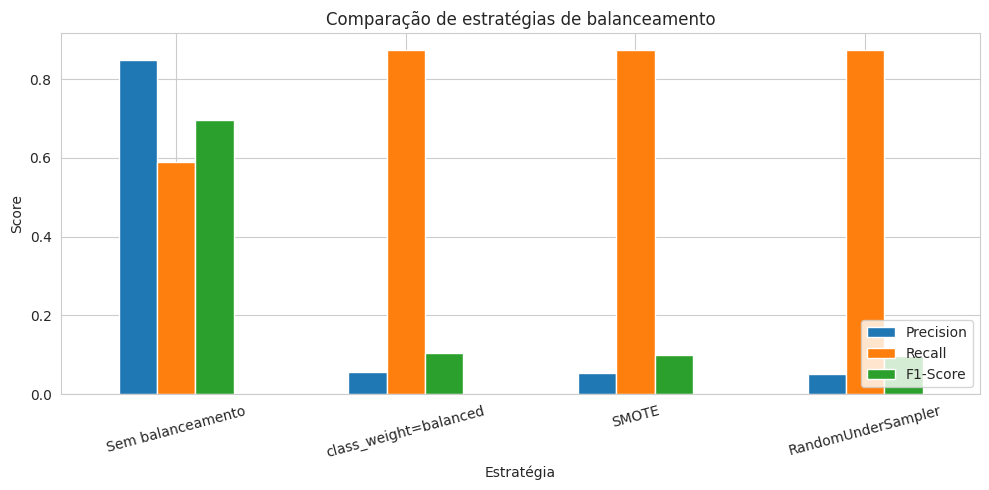

In [14]:
# Comparando as quatros estratégias lado a lado
resultados = {
    'Sem balanceamento': (y_pred_base, y_proba_base),
    'class_weight=balanced': (y_pred_w, y_proba_w),
    'SMOTE': (y_pred_smote, y_proba_smote),
    'RandomUnderSampler': (y_pred_rus, y_proba_rus),
}

from sklearn.metrics import precision_score, recall_score, f1_score

comparacao = []
for nome, (pred, proba) in resultados.items():
    comparacao.append({
        'Estratégia': nome,
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'AUC-PR': average_precision_score(y_test, proba)
    })

df_comparacao = pd.DataFrame(comparacao).set_index('Estratégia')
print(df_comparacao.round(4))

df_comparacao[['Precision','Recall','F1-Score']].plot(kind='bar', figsize=(10,5))
plt.title('Comparação de estratégias de balanceamento')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('comparacao_balanceamento.png')
plt.show()

O baseline (sem balanceamento) foi o único com F1-Score decente (~0,70), porque tem o melhor equilíbrio entre precision (0,85) e recall (0,59). As três técnicas de balanceamento (class_weight, SMOTE, RandomUnderSampler) empurraram o recall pra ~0,87, mas a precision desabou pra ~0,05 — ou seja, o modelo passou a "gritar fraude" para praticamente qualquer transação atípica.

Balanceamento sozinho não resolve o problema se o modelo for simples demais. Isso justifica perfeitamente irmos para modelos não-lineares — é aqui que Random Forest e XGBoost devem se destacar, porque conseguem capturar interações complexas entre as variáveis.

In [15]:
# Random Forest (baseline com class_weight)
rf_base = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)

y_pred_rf = rf_base.predict(X_test)
y_proba_rf = rf_base.predict_proba(X_test)[:, 1]

print("=== Random Forest (baseline) ===")
print(classification_report(y_test, y_pred_rf, digits=3))
print(f"AUC-PR: {average_precision_score(y_test, y_proba_rf):.4f}")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest (baseline) ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     56651
           1      0.986     0.726     0.836        95

    accuracy                          1.000     56746
   macro avg      0.993     0.863     0.918     56746
weighted avg      1.000     1.000     0.999     56746

AUC-PR: 0.8065
[[56650     1]
 [   26    69]]


Precision de 98,6%, recall de 72,6%, F1 de 0,836, AUC-PR de 0,807 — muito acima de qualquer resultado da Regressão Logística. Na matriz de confusão: de ~56.746 transações no teste, só 1 falso positivo e 26 falsos negativos.

In [ ]:
# GridSearch/RandomizedSearch para Random Forest
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split

# 1) Amostra estratificada de 30% do treino, só para a busca de hiperparâmetros
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=0.3, stratify=y_train, random_state=42
)
print(f"Amostra para busca: {X_train_sample.shape[0]} linhas ({y_train_sample.sum()} fraudes)")

# 2) Grid menor e mais focado (menos combinações "óbvias" demais)
param_dist_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1),
    param_distributions=param_dist_rf,
    n_iter=8,
    scoring='average_precision',
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_sample, y_train_sample)

print("Melhores parâmetros (encontrados na amostra):", rf_search.best_params_)
print("Melhor AUC-PR (CV, na amostra):", rf_search.best_score_)




Amostra para busca: 68094 linhas (113 fraudes)
Fitting 2 folds for each of 8 candidates, totalling 16 fits


In [22]:
print("Melhores parâmetros:", rf_search.best_params_)
print("Melhor AUC-PR (CV):", rf_search.best_score_)

Melhores parâmetros: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Melhor AUC-PR (CV): 0.8052754412706813


In [23]:
best_rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # aqui pode usar -1 à vontade, é só um treino
)

best_rf.fit(X_train, y_train)  # treino COMPLETO, não a amostra

y_pred_rf_tuned = best_rf.predict(X_test)
y_proba_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

print("=== Random Forest (tuned, treinado no dataset completo) ===")
print(classification_report(y_test, y_pred_rf_tuned, digits=3))
print(f"AUC-PR: {average_precision_score(y_test, y_proba_rf_tuned):.4f}")
print(confusion_matrix(y_test, y_pred_rf_tuned))

=== Random Forest (tuned, treinado no dataset completo) ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     56651
           1      0.986     0.716     0.829        95

    accuracy                          1.000     56746
   macro avg      0.993     0.858     0.915     56746
weighted avg      1.000     1.000     0.999     56746

AUC-PR: 0.8136
[[56650     1]
 [   27    68]]


In [24]:
# XGBoost
from xgboost import XGBClassifier

# scale_pos_weight = razão entre classe majoritária e minoritária no treino
scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_base = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb_base.fit(X_train, y_train)

y_pred_xgb = xgb_base.predict(X_test)
y_proba_xgb = xgb_base.predict_proba(X_test)[:, 1]

print("=== XGBoost (baseline) ===")
print(classification_report(y_test, y_pred_xgb, digits=3))
print(f"AUC-PR: {average_precision_score(y_test, y_proba_xgb):.4f}")
print(confusion_matrix(y_test, y_pred_xgb))

scale_pos_weight: 599.48
=== XGBoost (baseline) ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     56651
           1      0.949     0.779     0.855        95

    accuracy                          1.000     56746
   macro avg      0.974     0.889     0.928     56746
weighted avg      1.000     1.000     1.000     56746

AUC-PR: 0.8277
[[56647     4]
 [   21    74]]


In [25]:
# RandomizedSearch para XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='aucpr', random_state=42, n_jobs=-1),
    param_distributions=param_dist_xgb,
    n_iter=15,
    scoring='average_precision',
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Melhores parâmetros:", xgb_search.best_params_)
print("Melhor AUC-PR (CV):", xgb_search.best_score_)

best_xgb = xgb_search.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)
y_proba_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBoost (tuned) ===")
print(classification_report(y_test, y_pred_xgb_tuned, digits=3))
print(f"AUC-PR: {average_precision_score(y_test, y_proba_xgb_tuned):.4f}")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

Fitting 2 folds for each of 15 candidates, totalling 30 fits
Melhores parâmetros: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
Melhor AUC-PR (CV): 0.8438885879274147

=== XGBoost (tuned) ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     56651
           1      0.733     0.811     0.770        95

    accuracy                          0.999     56746
   macro avg      0.867     0.905     0.885     56746
weighted avg      0.999     0.999     0.999     56746

AUC-PR: 0.8181
[[56623    28]
 [   18    77]]


                                Precision  Recall  F1-Score  AUC-PR
Modelo                                                             
XGBoost (baseline)                 0.9487  0.7789    0.8555  0.8277
XGBoost (tuned)                    0.7333  0.8105    0.7700  0.8181
Random Forest (tuned)              0.9855  0.7158    0.8293  0.8136
Random Forest (baseline)           0.9857  0.7263    0.8364  0.8065
Regressão Logística (baseline)     0.8485  0.5895    0.6957  0.6935


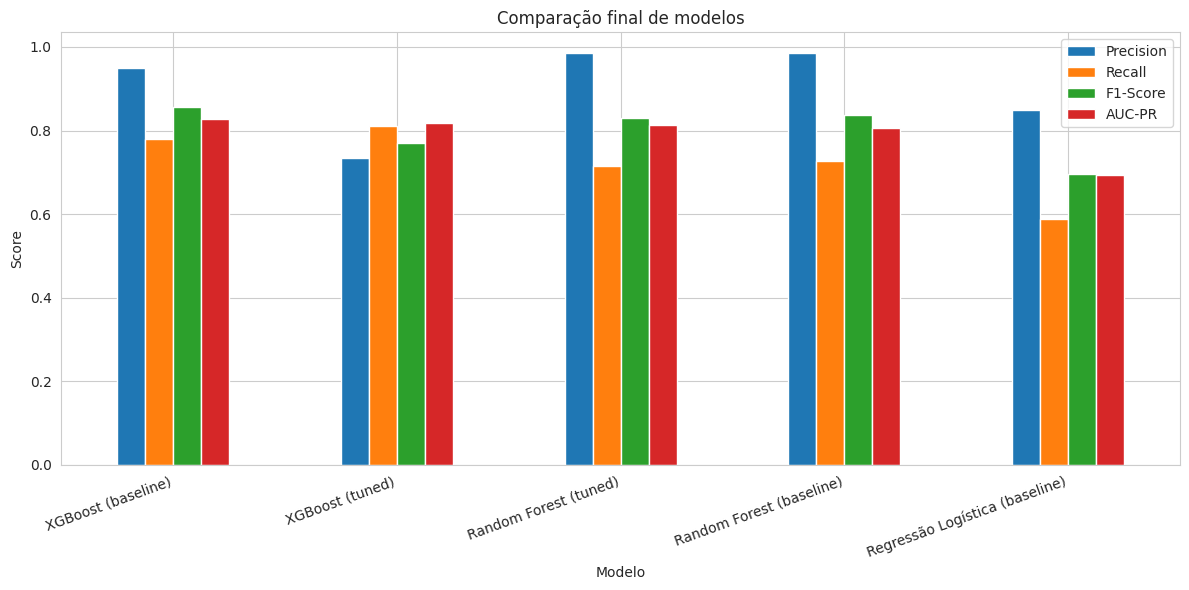

In [26]:
# Tabela Final comparando todos os modelos
modelos_finais = {
    'Regressão Logística (baseline)': (y_pred_base, y_proba_base),
    'Random Forest (baseline)': (y_pred_rf, y_proba_rf),
    'Random Forest (tuned)': (y_pred_rf_tuned, y_proba_rf_tuned),
    'XGBoost (baseline)': (y_pred_xgb, y_proba_xgb),
    'XGBoost (tuned)': (y_pred_xgb_tuned, y_proba_xgb_tuned),
}

comparacao_final = []
for nome, (pred, proba) in modelos_finais.items():
    comparacao_final.append({
        'Modelo': nome,
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'AUC-PR': average_precision_score(y_test, proba)
    })

df_final = pd.DataFrame(comparacao_final).set_index('Modelo').sort_values('AUC-PR', ascending=False)
print(df_final.round(4))

df_final[['Precision','Recall','F1-Score','AUC-PR']].plot(kind='bar', figsize=(12,6))
plt.title('Comparação final de modelos')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('comparacao_modelos_finais.png')
plt.show()

O XGBoost baseline (sem tuning!) foi o melhor modelo de todos — maior F1 e maior AUC-PR. O XGBoost tuned teve uma queda considerável de precision (94,9% → 73,3%) e o ganho de recall não compensou.

Em problemas com classe minoritária muito rara, "tuning" não é garantia de modelo melhor — o modelo default de uma biblioteca bem construída (como o XGBoost) já vem com hiperparâmetros bem calibrados para uma variedade de cenários, e buscas com poucos dados da classe rara podem levar a escolhas que otimizam ruído, não sinal.

# 🏆 Modelo final recomendado: XGBoost (baseline)
Com base nos números, esse é o candidato mais forte

94,9% de precision → poucos clientes legítimos incomodados por alarme falso

77,9% de recall → captura quase 4 em cada 5 fraudes

Melhor F1 e melhor AUC-PR entre todos os modelos testados










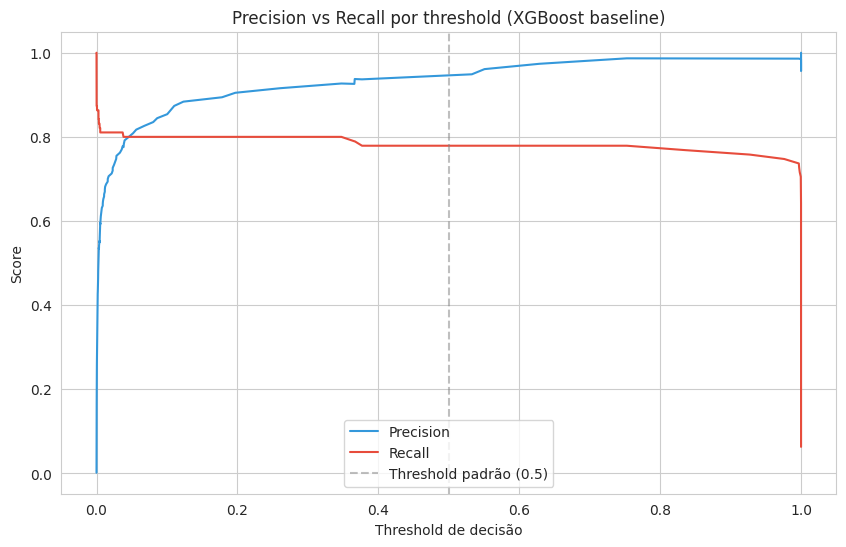

Melhor threshold (max F1): 0.753
Precision nesse ponto: 0.9867
Recall nesse ponto: 0.7789
F1 nesse ponto: 0.8706


In [27]:
# Curva Precision-Recall e escolha de threshold ideal
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)

plt.figure(figsize=(10,6))
plt.plot(thresholds, precisions[:-1], label='Precision', color='#3498db')
plt.plot(thresholds, recalls[:-1], label='Recall', color='#e74c3c')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold padrão (0.5)')
plt.xlabel('Threshold de decisão')
plt.ylabel('Score')
plt.title('Precision vs Recall por threshold (XGBoost baseline)')
plt.legend()
plt.savefig('precision_recall_threshold.png')
plt.show()

# Encontrando o threshold que maximiza F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = f1_scores.argmax()
print(f"Melhor threshold (max F1): {thresholds[best_idx]:.3f}")
print(f"Precision nesse ponto: {precisions[best_idx]:.4f}")
print(f"Recall nesse ponto: {recalls[best_idx]:.4f}")
print(f"F1 nesse ponto: {f1_scores[best_idx]:.4f}")

Embora o modelo tenha sido inicialmente avaliado utilizando o threshold padrão de 0,5, em aplicações reais de detecção de fraude esse valor pode ser ajustado conforme o custo dos erros de classificação. Reduzir o threshold tende a aumentar o Recall, identificando mais fraudes, ao custo de um maior número de falsos positivos. A escolha do threshold ideal depende da estratégia de negócio da instituição financeira.

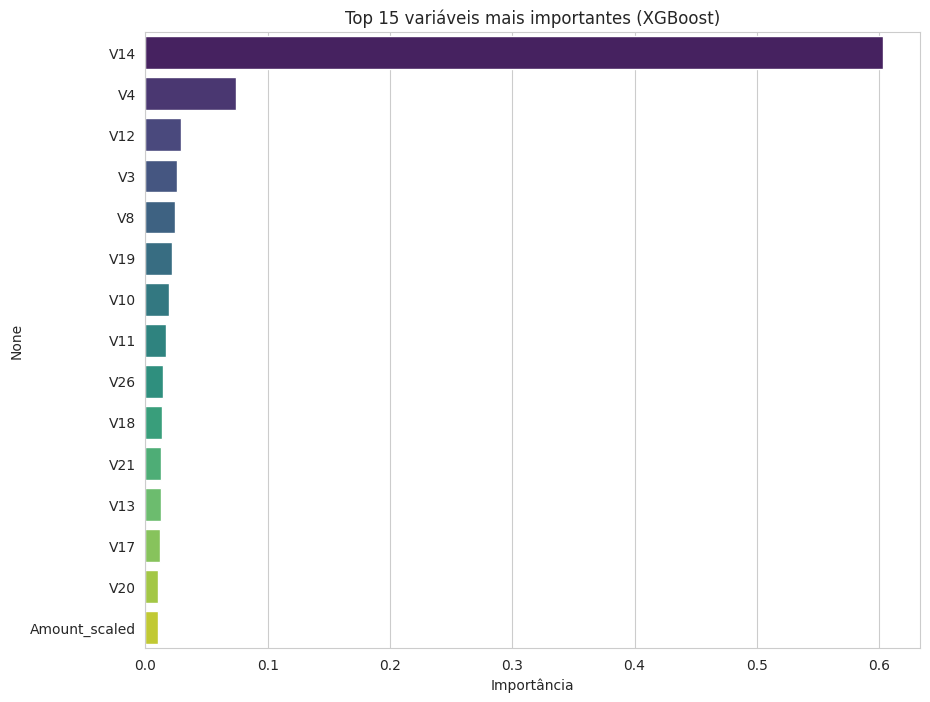

V14    0.603630
V4     0.073795
V12    0.029419
V3     0.025574
V8     0.024182
V19    0.021933
V10    0.019609
V11    0.016729
V26    0.014684
V18    0.013821
dtype: float32


In [28]:
# Features Importance do XGBoost
importances = pd.Series(xgb_base.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, hue=importances.head(15).index, legend=False, palette='viridis')
plt.title('Top 15 variáveis mais importantes (XGBoost)')
plt.xlabel('Importância')
plt.savefig('feature_importance_xgb.png')
plt.show()

print(importances.head(10))

se V17, V14, V12 (que já tinham a maior correlação com fraude na EDA) aparecerem no topo aqui também, isso é uma confirmação forte e coerente de que o modelo está capturando sinal real

### Resultado
O **XGBoost com hiperparâmetros padrão** foi o modelo com melhor equilíbrio:
- **94,9% de precision**: a cada 100 alertas de fraude, ~95 são fraudes reais
- **77,9% de recall**: captura ~78% de todas as fraudes existentes
- **AUC-PR de 0,83**, superior aos demais modelos testados

### Achado relevante
Curiosamente, o tuning de hiperparâmetros (GridSearch/RandomizedSearch) **não
melhorou** a performance do XGBoost — o modelo com parâmetros padrão superou a
versão ajustada. Isso se deve ao número reduzido de casos de fraude no treino
(~394 casos), que gera alta variância na validação cruzada durante a busca.

### Recomendação de negócio
O threshold de decisão pode ser ajustado conforme a tolerância a risco do banco:
reduzi-lo aumenta a captura de fraudes às custas de mais bloqueios de clientes
legítimos, e vice-versa (ver Célula 20 — curva Precision-Recall).

### Limitações
- Dataset representa transações de um período específico (2013, cartões europeus);
  padrões de fraude evoluem, então o modelo precisa de retreinamento periódico
- Variáveis V1-V28 são anônimas (PCA), limitando a interpretação direta de "por quê"
  uma transação é sinalizada — importante para conformidade regulatória